In [22]:
from sklearn.datasets import load_diabetes
data = load_diabetes(as_frame=True)
df_X = data.data
df_y = data.target
df = data.frame

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [24]:
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


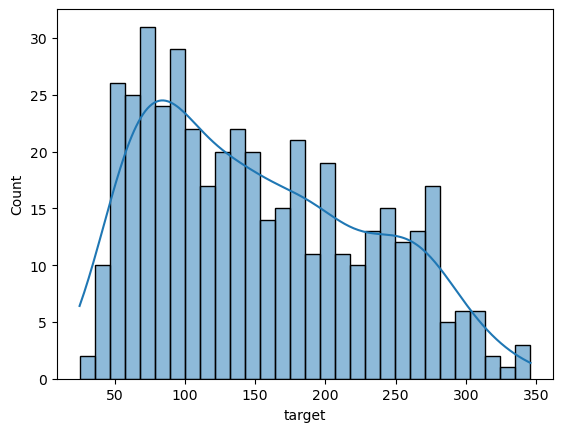

In [25]:
sns.histplot(data=df, x='target', bins=30, kde=True)
plt.show()

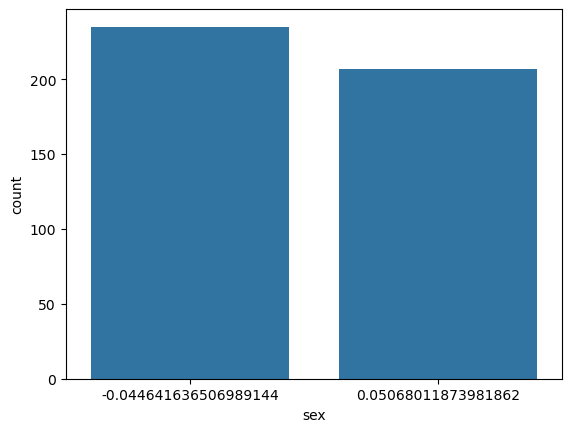

In [26]:
sns.countplot(data=df, x='sex')
plt.show()

In [27]:
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < (Q1 - 1.5 * IQR)) | (series > (Q3 + 1.5 * IQR))).sum()

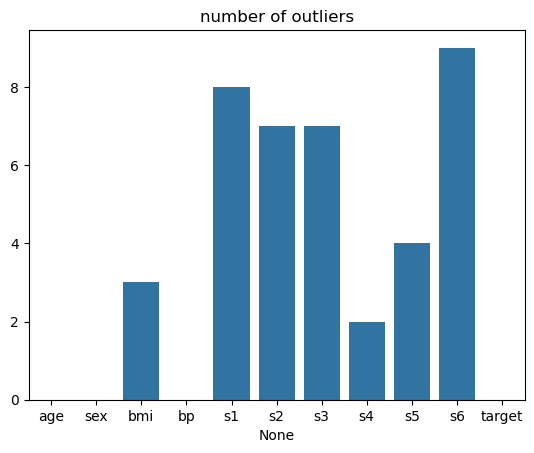

In [28]:
n_outliers = df.apply(count_outliers)
sns.barplot(x=n_outliers.index,y=n_outliers.values)
plt.title("number of outliers")
plt.show()

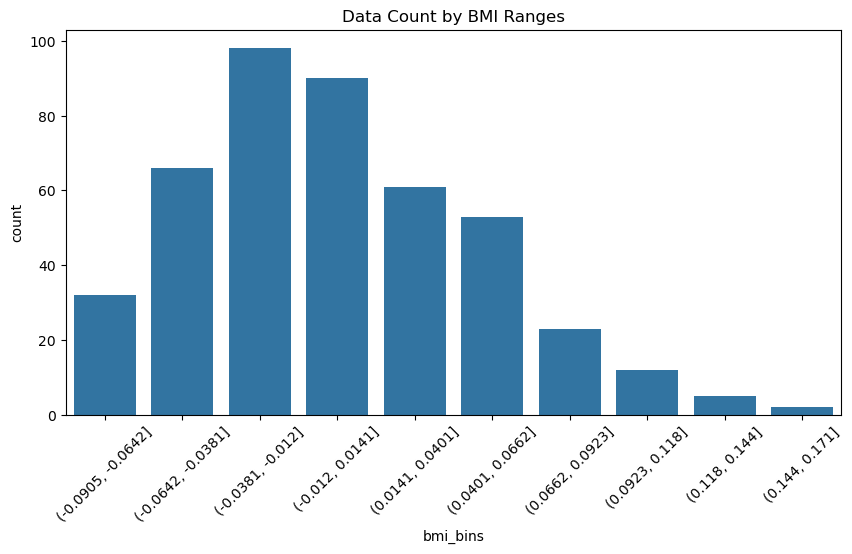

In [29]:
import pandas as pd

df['bmi_bins'] = pd.cut(df['bmi'], bins=10)

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='bmi_bins')
plt.title("Data Count by BMI Ranges")
plt.xticks(rotation=45)
plt.show()

In [30]:
null_counts = df.isnull().sum()
null_counts

age         0
sex         0
bmi         0
bp          0
s1          0
s2          0
s3          0
s4          0
s5          0
s6          0
target      0
bmi_bins    0
dtype: int64

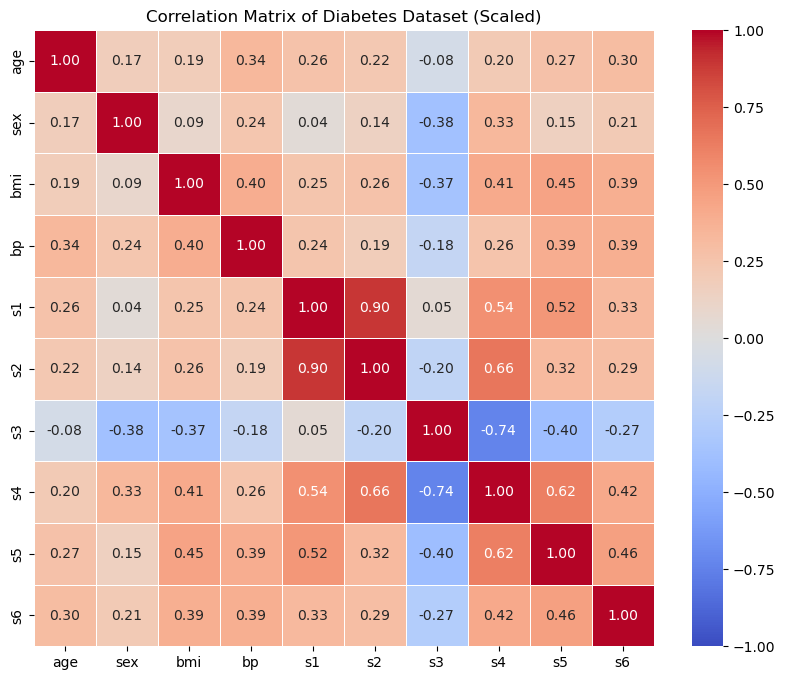

In [31]:

pure_features = df.drop(columns=['target', 'bmi_bins'], errors='ignore')
corr_matrix = pure_features.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,       # 격자 안에 실제 상관계수 숫자 표시
    fmt=".2f",        # 소수점 둘째 자리까지 표현
    cmap="coolwarm",  # 양의 상관관계는 빨간색, 음의 상관관계는 파란색
    vmin=-1, vmax=1,   # 상관계수 범위 고정 (-1 ~ 1)
    linewidths=0.5    # 셀 사이의 간격 격자선
)

plt.title("Correlation Matrix of Diabetes Dataset (Scaled)")
plt.show()

In [32]:
import numpy as np

X = np.array(df_X)
y = np.array(df_y)

In [33]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state=42)

In [34]:
print(X_train.shape, y_train.shape)
print(X_test.shape,y_test.shape)

(353, 10) (353,)
(89, 10) (89,)


In [35]:
W = np.random.rand(X_train.shape[1])
b = np.random.rand()

print(len(W))

10


In [36]:
def model(X, W, b):
    predictions = 0
    for i in range(len(W)):
        predictions += X[:, i] * W[i]
    predictions += b
    return predictions

In [37]:
def MSE(a, b):
    mse = ((a - b) ** 2).mean()  # 두 값의 차이의 제곱의 평균
    return mse

In [38]:
def loss(X, W, b, y):
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L

In [39]:
def gradient(X, W, b, y):
    N = len(y)

    y_pred = model(X, W, b)

    dW = 1/N * 2 * X.T.dot(y_pred - y)

    db = 2 * (y_pred - y).mean()
    return dW, db

In [40]:
LEARNING_RATE = 0.2

In [41]:
losses = []

In [42]:
%%timeit -n 1 -r 1
global W, b

for i in range(1, 2001):
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    if i % 100 == 0:
        print('Iteration %d : Loss %0.4f' % (i, L))

Iteration 100 : Loss 4875.6740
Iteration 200 : Loss 4220.9543
Iteration 300 : Loss 3838.8710
Iteration 400 : Loss 3601.0512
Iteration 500 : Loss 3442.8773
Iteration 600 : Loss 3331.1452
Iteration 700 : Loss 3248.2643
Iteration 800 : Loss 3184.5119
Iteration 900 : Loss 3134.2144
Iteration 1000 : Loss 3093.8475
Iteration 1100 : Loss 3061.0773
Iteration 1200 : Loss 3034.2658
Iteration 1300 : Loss 3012.2079
Iteration 1400 : Loss 2993.9855
Iteration 1500 : Loss 2978.8814
Iteration 1600 : Loss 2966.3261
Iteration 1700 : Loss 2955.8625
Iteration 1800 : Loss 2947.1206
Iteration 1900 : Loss 2939.7996
Iteration 2000 : Loss 2933.6539
220 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


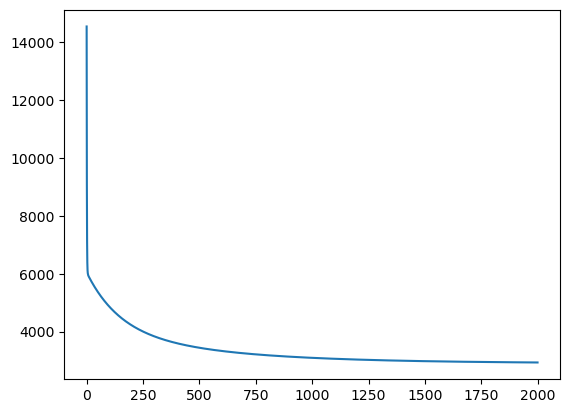

In [43]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.show()

In [44]:
prediction = model(X_test, W, b)
mse = loss(X_test, W, b, y_test)
mse

np.float64(2864.5310840453226)

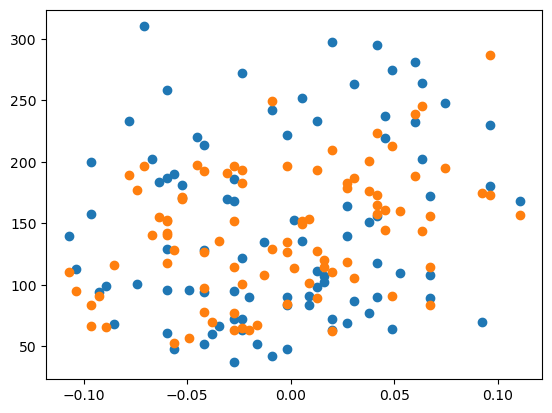

In [45]:
plt.scatter(X_test[:, 0], y_test)
plt.scatter(X_test[:, 0], prediction)
plt.show()

In [65]:
for i, col in enumerate(data.feature_names):
	print(f'feature {i+1} : {col}')

feature 1 : age
feature 2 : sex
feature 3 : bmi
feature 4 : bp
feature 5 : s1
feature 6 : s2
feature 7 : s3
feature 8 : s4
feature 9 : s5
feature 10 : s6


In [66]:
import sklearn
print(sklearn.__version__)

1.7.0
